$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 2.9

## 理论

我们构建的统计模型为：

$$
y = h(\boldsymbol{x}) + \epsilon
$$

其中 $h(\boldsymbol{x}) \sim GP(\mu, \tau^2R(\cdot))$，噪声项 $\epsilon$ 独立同分布，服从正态分布 $\epsilon \stackrel{iid}{\sim} \mathcal{N}(0, \sigma^2)$。现有数据集 $\{(\boldsymbol{x}_i, y_i)\}_{i=1}^n$。暂且假定参数 $\mu$、$\tau^2$、$\sigma^2$ 以及相关参数 $\boldsymbol{\theta}$ 均为已知量，后续将采用经验贝叶斯方法对这些参数进行估计。

设 $\boldsymbol{y} = (y_1, \dots, y_n)'$ 的边缘分布为

$$
\boldsymbol{y} \sim \mathcal{N}(\mu\boldsymbol{1}, \tau^2\boldsymbol{R} + \sigma^2\boldsymbol{I})
$$

而 $h(\boldsymbol{x})$ 与 $\boldsymbol{y}$ 的联合分布满足

$$
\begin{bmatrix}
h(\boldsymbol{x}) \\ \boldsymbol{y}
\end{bmatrix}
\sim \mathcal{N}_{1+n}
\left(\begin{bmatrix}
\mu \\ \mu\boldsymbol{1}
\end{bmatrix},
\begin{bmatrix}
\tau^2 & \tau^2\boldsymbol{r}(\boldsymbol{x})' \\
\tau^2\boldsymbol{r}(\boldsymbol{x}) & \tau^2\boldsymbol{R} + \sigma^2\boldsymbol{I}
\end{bmatrix}\right)
$$

式中 $\boldsymbol{r}(\boldsymbol{x}) = \{R(\boldsymbol{x} -\boldsymbol{x}_i)\}_{i=1}^n$，$\boldsymbol{R} = \{R(\boldsymbol{x}_i -\boldsymbol{x}_j)\}_{i,j=1}^n$。

利用引理 2.2，对于固定的 $\boldsymbol{x}$，可求得 $h(\boldsymbol{x})$ 的后验分布：

$$
h(\boldsymbol{x})|\boldsymbol{y} \sim \mathcal{N}\left( \mu + \boldsymbol{r}(\boldsymbol{x})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}(\boldsymbol{y}-\mu\boldsymbol{1}),\ \tau^2\left\{1-\boldsymbol{r}(\boldsymbol{x})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}\boldsymbol{r}(\boldsymbol{x})\right\} \right) \tag{2.43}
$$

其中 $\lambda = \sigma^2/\tau^2$。位置 $\boldsymbol{x}$ 处新增观测值的预测方差为：

$$
\begin{align*}
s^2(\boldsymbol{x}) &= var\{h(\boldsymbol{x})+\epsilon|\boldsymbol{y}\} \\
&= var\{h(\boldsymbol{x})|\boldsymbol{y}\} + var(\epsilon) \quad (\text{由相互独立性可得}) \\
&= \tau^2\left\{1+\lambda - \boldsymbol{r}(\boldsymbol{x})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}.
\end{align*}
$$

据此可得 95% 预测区间为 $\hat{y}(\boldsymbol{x}) \pm 2s(\boldsymbol{x})$。

高斯过程表达式还提供了一种不同于交叉验证法的方式来估计未知参数。参数的似然函数满足：

$$
L \propto \frac{1}{\tau^n |\boldsymbol{R}+\lambda\boldsymbol{I}|^{1/2}} \exp\left\{ -\frac{1}{2\tau^2}(\boldsymbol{y}-\mu\boldsymbol{1})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}(\boldsymbol{y}-\mu\boldsymbol{1}) \right\}
$$

将该似然函数关于 $\mu$、$\tau^2$、$\lambda$ 和 $\boldsymbol{\theta}$ 最大化，可得：

$$
\hat{\mu}=\frac{\boldsymbol{1}'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}\boldsymbol{y}}{\boldsymbol{1}'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}\boldsymbol{1}} \tag{2.44}
$$

$$
\hat{\tau}^2=\frac{1}{n}(\boldsymbol{y}-\hat{\mu}\boldsymbol{1})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}(\boldsymbol{y}-\hat{\mu}\boldsymbol{1}) \tag{2.45}
$$

$$
(\hat{\lambda},\hat{\boldsymbol{\theta}})=\argmin_{\lambda,\boldsymbol{\theta}} \left\{ n\log\hat{\tau}^2 + \log|\boldsymbol{R}+\lambda\boldsymbol{I}| \right\} \tag{2.46}
$$

再次考察由式 (2.1) 中的一维测试函数生成的 20 个数据点。借助 R 语言程序包 rkriging（黄与约瑟夫，2024），采用高斯相关函数 $R(u-v) = \exp\left\{-(u-v)^2/\theta^2\right\}$ 拟合高斯过程回归模型。针对两种采样方案——等间距采样点与适配九次多项式的 D 最优采样点，其预测结果及 95% 置信区间如图 2.9 所示。不出所料，该模型的预测效果与核岭回归相近，但高斯过程回归的优势在于可为预测值给出不确定性区间。对比图 2.6、图 2.7 右侧子图里的八次多项式模型，高斯过程回归无论是预测结果还是不确定性区间的表现都更为优异。高斯过程回归的不确定性区间具备合理特性：在已有观测数据的区间内区间宽度更窄，在数据稀疏区域区间则更宽。

## 实践

创建画布宽 20 英寸、高 10 英寸，将画布分为 1x2。依据公式

$$
h(x)=\frac{\sin(10\pi x)}{1 + 64(x - 0.25)^2} + x^2,\quad x\in[0,1]
\tag{2.1}
$$

定义函数 f(x)。在 $[0,1]$ 上等距选取 301 个点作为绘图点的横坐标，令其为 test，并计算 f(test) 作为绘图点的纵坐标，令其为 ture。令 n=10，依据均匀区间端点公式

$$
D=\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}
$$

取 1:n 上的等距 n 个点作为观测点的横坐标，命名为 D。令 r=2，将 D 重复 r 次作为每个点分别进行两次观测的点的横坐标，仍然令其为 D。设置种子为 1，从正态分布 $\mathcal{N}(0,0.1)$ 上随机选取 n*r 个点作为每次观测的误差，令其为 e。计算每个点对应的函数值作为点的纵坐标，再加上误差 e 作为含噪声的观测点的纵坐标，命名为 y。

绘制真实函数图像，其中类型为 l，线宽为 4，线型为 2，x 轴标注为 x，y 轴标注为 y，大小为 2，y 轴范围为 c(min(true)-.25,max(true)+.25)，大小为 2，标题为“高斯过程回归 (等距节点)”，大小为 3。叠加观测点图像，其中点型为 16，大小为 4，颜色为 blue。导入 rkriging 包，调用 Fit.Kriging() 函数对 (D,y) 拟合高斯过程回归模型，，其中不使用插值，核参数选择高斯核，为“Gaussian”字符串封装为列表，列名为 type，接着调用 Predict.Kriging() 函数，依据拟合模型，对 test 进行预测，将预测结果列表命名为 pred，其中 mean 列为预测值，sd 列为预测标准差。叠加预测值图像，其中颜色为 3，线宽为 5。由于噪声服从正态分布，故依据 2-$\sigma$ 原则，mean 列上下 2*sd 列即为 95% 预测区间的上下界，分别命名为 low，up。绘制预测区间图像，其中颜色为红色，透明度为 0.2，无边框。

由于 D 最优设计点定义在 $[-1,1]$ 上，因此需先将 test 映射到 $[-1,1]$ 上，令其为 tests。D 最优设计的候选点集就是 tests，故将其封装为数据框，列名为 x，数据框命名为 cand_df。导入 AlgDesign 包，调用 optFederov() 函数求解得到 D 最优设计，其中由于 $m=9$ 故选用 9 次多项式（包含截距项），最终选定 n 个试验点，候选点集为 cand_df，使用精确设计，设计列表命名为 a，其中的 design 列（共 1 列）即为最终选取的 D 最优设计点。将 design 列重复 r 次作为分别观测 r 次的观测点，记为 D。再将 D 映射回 $[0,1]$ 上，记为 D。最终计算 f(D) 再加上噪声 e 作为实际观测到的含噪声的观测点的纵坐标，令其为 y。

绘制真实函数图像，其中类型为 l，线宽为 4，线型为 2，x 轴标注为 x，y 轴标注为 y，大小为 2，y 轴范围为 c(min(true)-.25,max(true)+.25)，大小为 2，标题为“高斯过程回归 (D 最优设计)”，大小为 3。叠加观测点图像，其中点型为 16，大小为 4，颜色为 blue。调用 Fit.Kriging() 函数对 (D,y) 拟合高斯过程回归模型，，其中不使用插值，核参数选择高斯核，为“Gaussian”字符串封装为列表，列名为 type，接着调用 Predict.Kriging() 函数，依据拟合模型，对 test 进行预测，将预测结果列表命名为 pred，其中 mean 列为预测值，sd 列为预测标准差。叠加预测值图像，其中颜色为 3，线宽为 5。由于噪声服从正态分布，故依据 2-$\sigma$ 原则，mean 列上下 2*sd 列即为 95% 预测区间的上下界，分别命名为 low，up。绘制预测区间图像，其中颜色为红色，透明度为 0.2，无边框。添加图例，其中位置为 (0.25,-0.4)，图例内容为 c("真实值","预测值")，线型为 c(2,1)，颜色为 c(1,3)，线宽为 c(3,4)，边框类型为 n，大小为 2。将画布还原回 1x1。

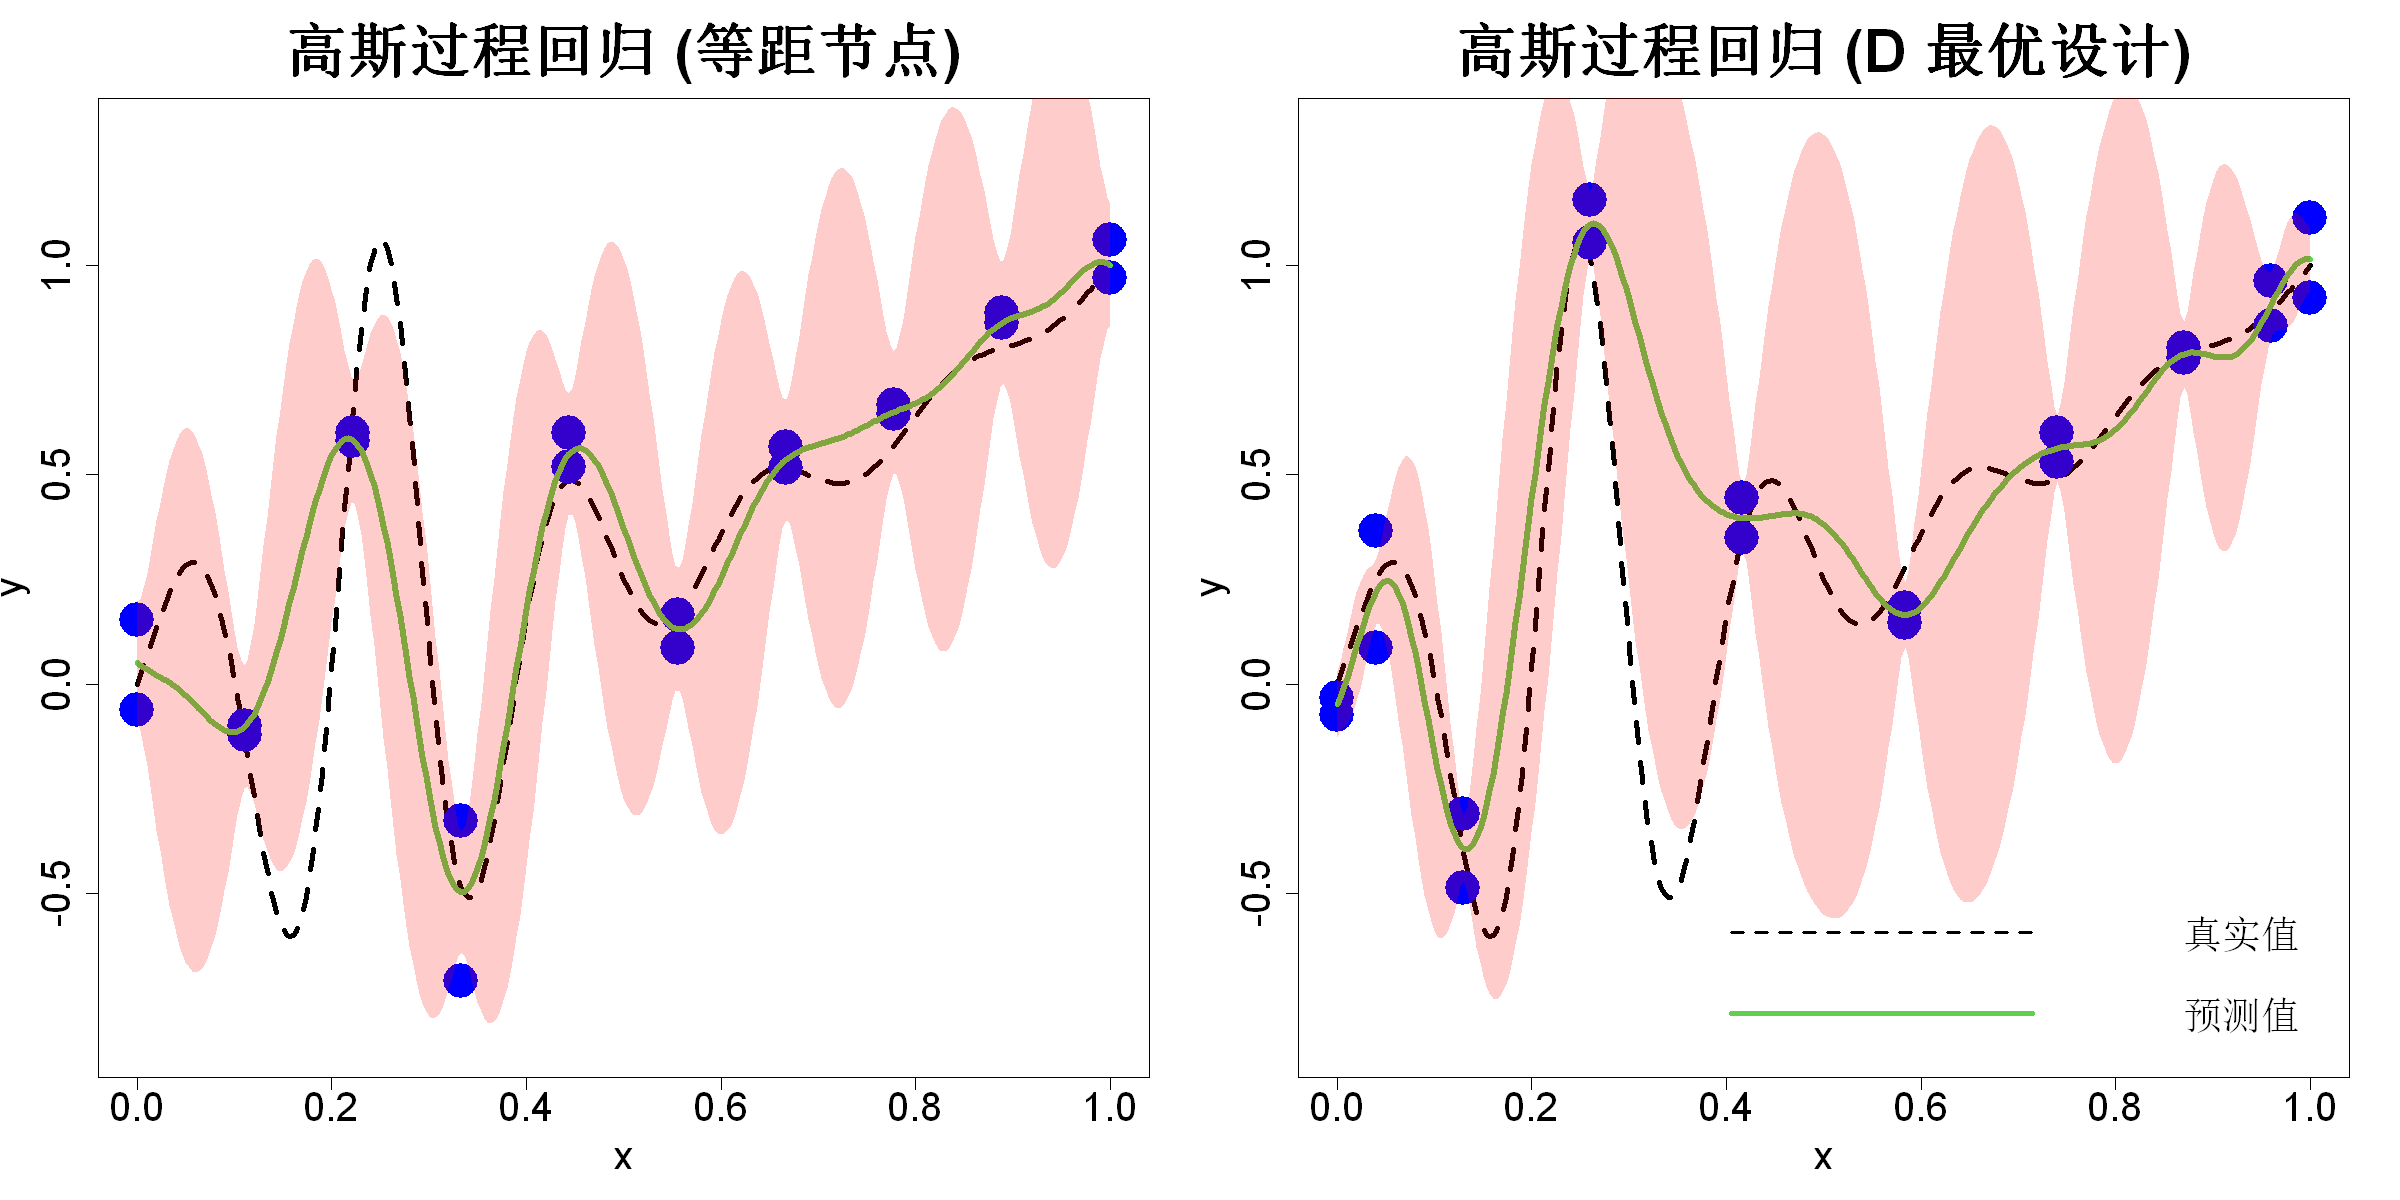

In [ ]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
r=2
D=((1:n)-1)/(n-1)
D=rep(D,r)
set.seed(1)
e=rnorm(n*r,sd=.1)
y=f(D)+e

plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="高斯过程回归 (等距节点)",cex.main=3,cex.lab=2,cex.axis=2)
points(D,y,pch=16,cex=4,col="blue")
library(rkriging)
pred=Fit.Kriging(D,y,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))|>
Predict.Kriging(test)
lines(test,pred$mean,col=3,lwd=5)
low=pred$mean-2*pred$sd
up=pred$mean+2*pred$sd
polygon(c(test,rev(test)),c(low,rev(up)),col=adjustcolor("red",0.2),border=NA)

tests=2*test-1
cand_df=data.frame(x=tests)
library(AlgDesign)
a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand_df,approximate=FALSE)
D=rep(c(a$design[,1]),r)
D=(D+1)/2
D=rep(D,r)
e=rnorm(n*r,sd=.1)
y=f(D)+e

plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="高斯过程回归 (D 最优设计)",cex.main=3,cex.lab=2,cex.axis=2)
points(D,y,pch=16,cex=4,col="blue")
pred=Fit.Kriging(D,y,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))|>
Predict.Kriging(test)
lines(test,pred$mean,col=3,lwd=5)
low=pred$mean-2*pred$sd
up=pred$mean+2*pred$sd
polygon(c(test,rev(test)),c(low,rev(up)),col=adjustcolor("red",0.2),border=NA)
legend(.25,-.4,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n",cex=2)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$